In [121]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
df=pd.read_csv('/content/car details v4.csv')

In [58]:
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

In [60]:
df.drop_duplicates(inplace=True)

In [61]:
df.isnull().sum()

,0
Make,0
Model,0
Price,0
Year,0
Kilometer,0
Fuel Type,0
Transmission,0
Location,0
Color,0
Owner,0


In [62]:
df["Engine"] = df["Engine"].str.replace(" cc", "")

In [63]:
df["Engine"]

,Engine
0,1198
1,1248
2,1197
3,1197
4,2393
...,...
2054,2179
2055,814
2056,1196
2057,1995


In [64]:
df["Engine"] = df["Engine"].astype(float)

In [65]:
df.Engine

,Engine
0,1198.0
1,1248.0
2,1197.0
3,1197.0
4,2393.0
...,...
2054,2179.0
2055,814.0
2056,1196.0
2057,1995.0


In [66]:
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198.0,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248.0,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197.0,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197.0,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393.0,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [67]:
df["Max Power"].value_counts()

,count
Max Power,
89 bhp @ 4000 rpm,90
82 bhp @ 6000 rpm,62
126 bhp @ 4000 rpm,55
83 bhp @ 6000 rpm,55
74 bhp @ 4000 rpm,50
...,...
198@4000,1
247 bhp @ 5500 rpm,1
197 bhp @ 5000 rpm,1


In [68]:
df["Max Power"] = df["Max Power"].str.replace("bhp", "", regex=False)
df["Max Power"] = df["Max Power"].str.replace("rpm", "", regex=False)

In [69]:
df[["Maxpower", "rpm_power"]] = df["Max Power"].str.split("@", expand=True)

In [70]:
df["Maxpower"] = df["Maxpower"].str.strip()
df["rpm_power"] = df["rpm_power"].str.strip()

In [71]:
df["Maxpower"] = pd.to_numeric(df["Maxpower"], errors="coerce")
df["rpm_power"] = pd.to_numeric(df["rpm_power"], errors="coerce")

In [72]:
df.drop("Max Power", axis=1, inplace=True)

In [73]:
df["Max Torque"].value_counts()

,count
Max Torque,
200 Nm @ 1750 rpm,90
115 Nm @ 4000 rpm,78
114 Nm @ 4000 rpm,66
90 Nm @ 3500 rpm,64
400 Nm @ 1750 rpm,63
...,...
500@1500,1
150 Nm @ 1750 rpm,1
300 Nm @ 1300 rpm,1


In [74]:
df["Max Torque"].unique()

array(['109 Nm @ 4500 rpm', '190 Nm @ 2000 rpm', '112.7619 Nm @ 4000 rpm',
       '113 Nm @ 4200 rpm', '343 Nm @ 1400 rpm', '130 Nm @ 4000 rpm',
       '300 Nm @ 1200 rpm', '400 Nm @ 1750 rpm', '250 Nm @ 1250 rpm',
       '200 Nm @ 1900 rpm', '115 Nm @ 4000 rpm', '91 Nm @ 4250 rpm',
       '138 Nm @ 4400 rpm', '350 Nm @ 1750 rpm', '175 Nm @ 1500 rpm',
       '90 Nm @ 3500 rpm', '69 Nm @ 3500 rpm', '154 Nm @ 4850 rpm',
       '153 Nm @ 3800 rpm', '99 Nm @ 4500 rpm', '172 Nm @ 1500 rpm',
       '78 Nm @ 3500 rpm', '113 Nm @ 4500 rpm', '110 Nm @ 4800 rpm',
       '265 Nm @ 1900 rpm', '170 Nm @ 1400 rpm', nan, '96 Nm @ 3000 rpm',
       '114 Nm @ 3500 rpm', '140 Nm @ 1800 rpm', '400 Nm @ 1400 rpm',
       '260 Nm @ 1500 rpm', '500 Nm @ 1600 rpm', '173 Nm @ 4000 rpm',
       '380 Nm @ 1750 rpm', '240@3000', '247 Nm @ 1800 rpm',
       '200 Nm @ 1750 rpm', '200 Nm @ 1200 rpm', '290 Nm @ 1800 rpm',
       '270 Nm @ 1350 rpm', '145 Nm @ 4600 rpm', '180 Nm @ 2000 rpm',
       '101 Nm @ 3000 rpm

In [75]:
df["Max Torque"] = df["Max Torque"].str.replace("Nm", "", regex=False)
df["Max Torque"] = df["Max Torque"].str.replace("rpm", "", regex=False)

In [76]:
df[["MaxTorque", "rpm_torque"]] = df["Max Torque"].str.split("@", expand=True)

In [77]:
df["MaxTorque"] = df["MaxTorque"].str.strip()
df["rpm_torque"] = df["rpm_torque"].str.strip()

In [78]:
df["MaxTorque"] = pd.to_numeric(df["MaxTorque"], errors="coerce")
df["rpm_torque"] = pd.to_numeric(df["rpm_torque"], errors="coerce")

In [79]:
df.drop("Max Torque", axis=1, inplace=True)

In [80]:
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,...,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Maxpower,rpm_power,MaxTorque,rpm_torque
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,...,FWD,3990.0,1680.0,1505.0,5.0,35.0,87.0,6000.0,109.0000,4500.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,...,FWD,3995.0,1695.0,1555.0,5.0,42.0,74.0,4000.0,190.0000,2000.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,...,FWD,3585.0,1595.0,1550.0,5.0,35.0,79.0,6000.0,112.7619,4000.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,...,FWD,3995.0,1745.0,1510.0,5.0,37.0,82.0,6000.0,113.0000,4200.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,...,RWD,4735.0,1830.0,1795.0,7.0,55.0,148.0,3400.0,343.0000,1400.0


In [81]:
df.describe()

,Price,Year,Kilometer,Engine,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Maxpower,rpm_power,MaxTorque,rpm_torque
count,2.059000e+03,2059.000000,2.059000e+03,1979.000000,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000,1979.000000,1975.000000,1979.000000,1979.000000
mean,1.702992e+06,2016.425449,5.422471e+04,1692.575543,4280.860652,1767.991980,1591.735338,5.306266,52.002210,129.611774,4835.093671,245.851019,2619.545225
std,2.419881e+06,3.363564,5.736172e+04,643.736294,442.458507,135.265825,136.073956,0.822170,15.110198,65.073797,1097.368548,140.465731,1206.314770
min,4.900000e+04,1988.000000,0.000000e+00,624.000000,3099.000000,1475.000000,1165.000000,2.000000,15.000000,35.000000,2910.000000,48.000000,150.000000
25%,4.849990e+05,2014.000000,2.900000e+04,1197.000000,3985.000000,1695.000000,1485.000000,5.000000,41.250000,83.000000,4000.000000,115.000000,1600.000000
50%,8.250000e+05,2017.000000,5.000000e+04,1498.000000,4370.000000,1770.000000,1545.000000,5.000000,50.000000,116.000000,4200.000000,200.000000,1900.000000
75%,1.925000e+06,2019.000000,7.200000e+04,1995.000000,4629.000000,1831.500000,1675.000000,5.000000,60.000000,171.000000,6000.000000,350.000000,4000.000000
max,3.500000e+07,2022.000000,2.000000e+06,6592.000000,5569.000000,2220.000000,1995.000000,8.000000,105.000000,660.000000,8250.000000,780.000000,6500.000000


In [82]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]

In [83]:
df.shape

(1844, 22)

In [84]:
df.isna().sum()

,0
Make,0
Model,0
Price,0
Year,0
Kilometer,0
Fuel Type,0
Transmission,0
Location,0
Color,0
Owner,0


In [85]:
df.Engine=df.Engine.fillna(df.Engine.mean())

In [86]:
df.Drivetrain.unique()

array(['FWD', 'RWD', 'AWD', nan], dtype=object)

In [87]:
df['Drivetrain'] = df.groupby('Make')['Drivetrain'].transform(lambda x: x.fillna(x.mode()[0]))

In [88]:
df['Length'] = df.groupby('Make')['Length'].transform(lambda x: x.fillna(x.median()))
df['Width'] = df.groupby('Make')['Width'].transform(lambda x: x.fillna(x.median()))
df['Height'] = df.groupby('Make')['Height'].transform(lambda x: x.fillna(x.median()))

In [89]:
df['Seating Capacity'].fillna(df['Seating Capacity'].mode()[0], inplace=True)

/tmp/ipykernel_2018/2668270759.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Seating Capacity'].fillna(df['Seating Capacity'].mode()[0], inplace=True)


In [90]:
df['Fuel Tank Capacity'].fillna(df['Fuel Tank Capacity'].median(), inplace=True)

/tmp/ipykernel_2018/4253464452.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Fuel Tank Capacity'].fillna(df['Fuel Tank Capacity'].median(), inplace=True)


In [91]:
df['Maxpower'] = df.groupby('Engine')['Maxpower'].transform(lambda x: x.fillna(x.median()))
df['MaxTorque'] = df.groupby('Engine')['MaxTorque'].transform(lambda x: x.fillna(x.median()))

In [92]:
df['rpm_power'] = df.groupby('Maxpower')['rpm_power'].transform(lambda x: x.fillna(x.median()))
df['rpm_torque'] = df.groupby('MaxTorque')['rpm_torque'].transform(lambda x: x.fillna(x.median()))

In [93]:
df.isna().sum()

,0
Make,0
Model,0
Price,0
Year,0
Kilometer,0
Fuel Type,0
Transmission,0
Location,0
Color,0
Owner,0


In [94]:
df['Maxpower'].fillna(df['Maxpower'].median(), inplace=True)
df['MaxTorque'].fillna(df['MaxTorque'].median(), inplace=True)
df['rpm_power'].fillna(df['rpm_power'].median(), inplace=True)
df['rpm_torque'].fillna(df['rpm_torque'].median(), inplace=True)

/tmp/ipykernel_2018/3225646718.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Maxpower'].fillna(df['Maxpower'].median(), inplace=True)
/tmp/ipykernel_2018/3225646718.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

In [95]:
df.isna().sum()

,0
Make,0
Model,0
Price,0
Year,0
Kilometer,0
Fuel Type,0
Transmission,0
Location,0
Color,0
Owner,0


In [96]:
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,...,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Maxpower,rpm_power,MaxTorque,rpm_torque
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,...,FWD,3990.0,1680.0,1505.0,5.0,35.0,87.0,6000.0,109.0000,4500.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,...,FWD,3995.0,1695.0,1555.0,5.0,42.0,74.0,4000.0,190.0000,2000.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,...,FWD,3585.0,1595.0,1550.0,5.0,35.0,79.0,6000.0,112.7619,4000.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,...,FWD,3995.0,1745.0,1510.0,5.0,37.0,82.0,6000.0,113.0000,4200.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,...,RWD,4735.0,1830.0,1795.0,7.0,55.0,148.0,3400.0,343.0000,1400.0


In [97]:
df.columns

Index(['Make', 'Model', 'Price', 'Year', 'Kilometer', 'Fuel Type',
       'Transmission', 'Location', 'Color', 'Owner', 'Seller Type', 'Engine',
       'Drivetrain', 'Length', 'Width', 'Height', 'Seating Capacity',
       'Fuel Tank Capacity', 'Maxpower', 'rpm_power', 'MaxTorque',
       'rpm_torque'],
      dtype='object')

In [98]:
lb=LabelEncoder()
l=["Fuel Type", "Transmission", "Owner", "Seller Type", "Drivetrain"]
for i in l:
  df[i]=lb.fit_transform(df[i])

In [99]:
df["Fuel Type"]

,Fuel Type
0,5
1,2
2,5
3,5
4,2
...,...
2053,5
2054,2
2055,5
2056,5


In [109]:
X = df.drop(["Price","Make","Model","Location","Color"], axis=1)
y = df["Price"]

In [110]:
X_train,X_test,y_train,y_test=train_test_split(X , y, test_size=0.2 , random_state=42)

In [111]:
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [116]:
y_pred_lr = lr.predict(X_test)

In [117]:
dt=DecisionTreeRegressor(random_state=42)
dt.fit(X_train,y_train)

DecisionTreeRegressor(random_state=42)

In [118]:
y_pred_dt = dt.predict(X_test)

In [119]:
rf=RandomForestRegressor(n_estimators=100 , random_state=42)
rf.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [120]:
y_pred_rf = rf.predict(X_test)

In [122]:
print("Linear Regression")

print("MAE :", mean_absolute_error(y_test, y_pred_lr))
print("MSE :", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 :", r2_score(y_test, y_pred_lr))

Linear Regression
MAE : 311138.8987579266
MSE : 220436389137.66782
RMSE: 469506.5379072669
R2 : 0.7025554606318872


In [123]:
print("Decision Tree")

print("MAE :", mean_absolute_error(y_test, y_pred_dt))
print("MSE :", mean_squared_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2 :", r2_score(y_test, y_pred_dt))

Decision Tree
MAE : 169027.1056910569
MSE : 81823469501.43631
RMSE: 286048.019572652
R2 : 0.8895919848326135


In [124]:
print("Random Forest")

print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("MSE :", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 :", r2_score(y_test, y_pred_rf))

Random Forest
MAE : 158198.71297199637
MSE : 77936448496.06895
RMSE: 279171.00224784977
R2 : 0.8948369136620982


In [125]:
models = ["Linear Regression", "Decision Tree", "Random Forest"]

mae = [
    mean_absolute_error(y_test, y_pred_lr),
    mean_absolute_error(y_test, y_pred_dt),
    mean_absolute_error(y_test, y_pred_rf)
]

mse = [
    mean_squared_error(y_test, y_pred_lr),
    mean_squared_error(y_test, y_pred_dt),
    mean_squared_error(y_test, y_pred_rf)
]

rmse = [
    np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    np.sqrt(mean_squared_error(y_test, y_pred_dt)),
    np.sqrt(mean_squared_error(y_test, y_pred_rf))
]

r2 = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_dt),
    r2_score(y_test, y_pred_rf)
]

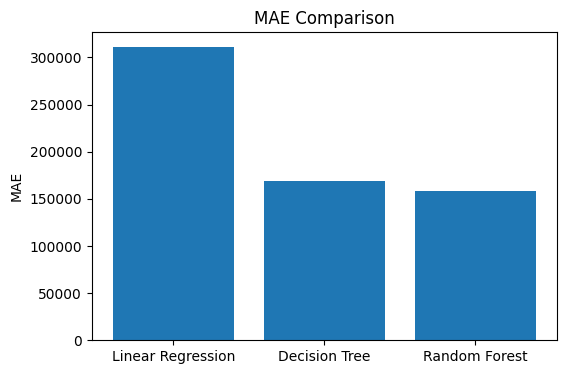

In [126]:
plt.figure(figsize=(6,4))
plt.bar(models, mae)
plt.title("MAE Comparison")
plt.ylabel("MAE")
plt.show()

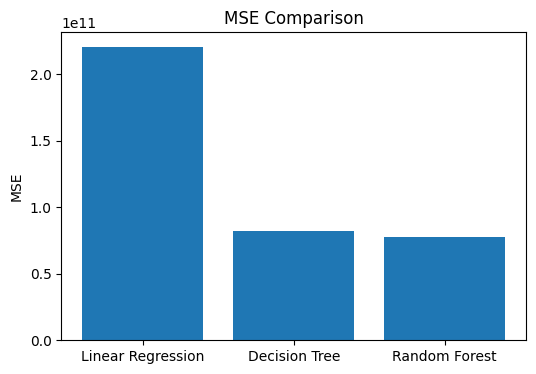

In [127]:
plt.figure(figsize=(6,4))
plt.bar(models, mse)
plt.title("MSE Comparison")
plt.ylabel("MSE")
plt.show()

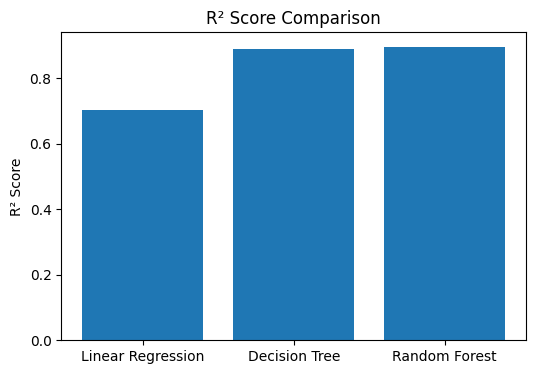

In [128]:
plt.figure(figsize=(6,4))
plt.bar(models, r2)
plt.title("R² Score Comparison")
plt.ylabel("R² Score")
plt.show()